<a href="https://colab.research.google.com/github/CCejudo98/financial-systems-lab/blob/main/notebooks/hrp_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[*********************100%***********************]  8 of 8 completed


--- Asignación de Pesos HRP ---
AAPL     0.066937
GLD      0.229816
GOOGL    0.050343
JPM      0.107296
MSFT     0.084971
NVDA     0.025646
TLT      0.343766
XOM      0.091226
dtype: float64


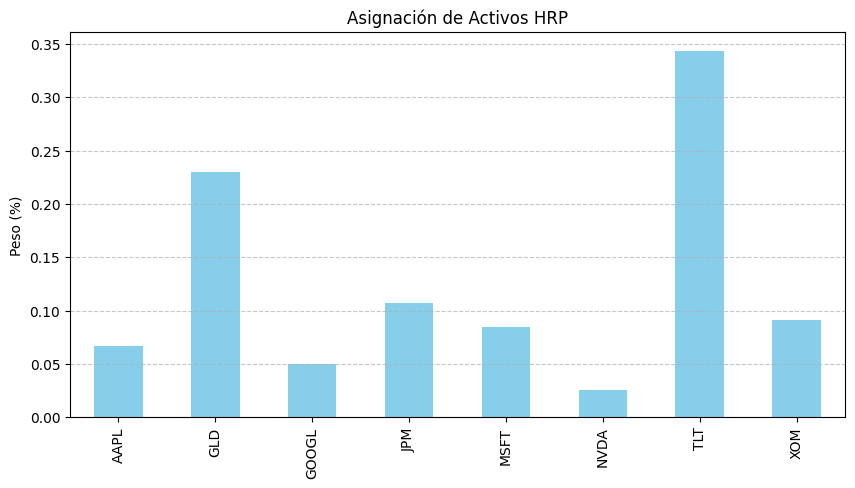

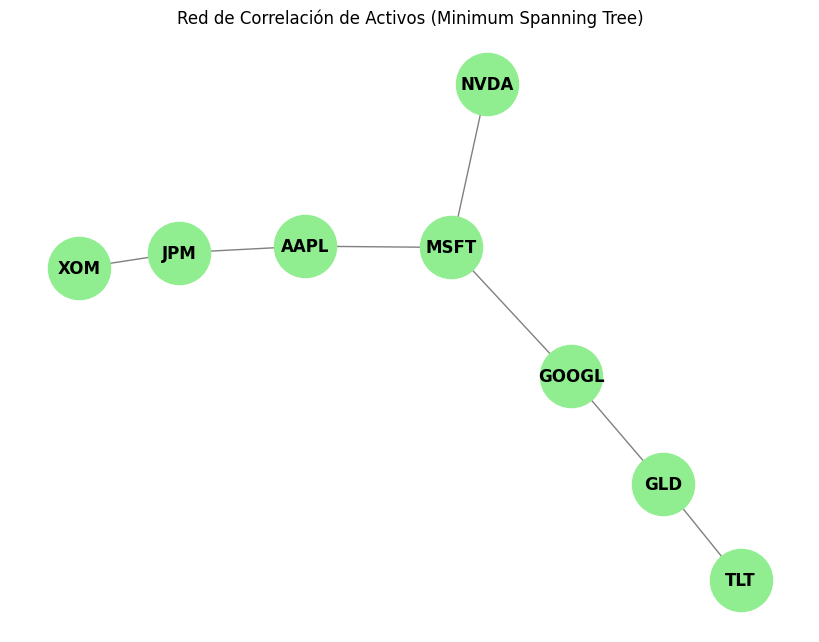

In [6]:
import yfinance as yf
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import scipy.cluster.hierarchy as sch

# 1. Definición del Motor HRP
class HierarchicalRiskParity:
    def __init__(self, returns: pd.DataFrame):
        self.returns = returns.dropna()
        self.cov = self.returns.cov()
        self.corr = self.returns.corr()

    def _get_distance_matrix(self) -> np.ndarray:
        dist = np.sqrt(np.clip(2 * (1 - self.corr.values), 0, None))
        dist = (dist + dist.T) / 2.0
        return dist

    def _get_quasi_diag(self, link: np.ndarray) -> list:
        link = link.astype(int)
        sort_ix = pd.Series([link[-1, 0], link[-1, 1]])
        num_items = link[-1, 3]
        while sort_ix.max() >= num_items:
            sort_ix.index = range(0, sort_ix.shape[0] * 2, 2)
            df0 = sort_ix[sort_ix >= num_items]
            i = df0.index
            j = df0.values - num_items
            sort_ix[i] = link[j, 0]
            df1 = pd.Series(link[j, 1], index=i + 1)
            sort_ix = pd.concat([sort_ix, df1])
            sort_ix = sort_ix.sort_index()
            sort_ix.index = range(sort_ix.shape[0])
        return sort_ix.tolist()

    def _get_cluster_var(self, cov: pd.DataFrame, c_items: list) -> float:
        # FIX: Se usa .loc en lugar de .iloc porque c_items contiene nombres de tickers
        cov_slice = cov.loc[c_items, c_items]
        ivp = 1.0 / np.diag(cov_slice)
        ivp /= ivp.sum()
        w = ivp.reshape(-1, 1)
        cluster_var = np.dot(np.dot(w.T, cov_slice), w)[0, 0]
        return cluster_var

    def _get_rec_bisection(self, cov: pd.DataFrame, sort_ix: list) -> pd.Series:
        w = pd.Series(1.0, index=sort_ix)
        c_items = [sort_ix]
        while len(c_items) > 0:
            c_items = [i[j:k] for i in c_items for j, k in ((0, len(i) // 2), (len(i) // 2, len(i))) if len(i) > 1]
            for i in range(0, len(c_items), 2):
                c_items0 = c_items[i]
                c_items1 = c_items[i + 1]
                var0 = self._get_cluster_var(cov, c_items0)
                var1 = self._get_cluster_var(cov, c_items1)
                alpha = 1.0 - var0 / (var0 + var1)
                w[c_items0] *= alpha
                w[c_items1] *= 1.0 - alpha
        return w

    def allocate(self) -> pd.Series:
        dist = self._get_distance_matrix()
        sq_dist = sch.distance.squareform(dist, checks=False)
        link = sch.linkage(sq_dist, method='ward')
        sort_ix = self._get_quasi_diag(link)
        sort_ix = self.corr.index[sort_ix].tolist()
        weights = self._get_rec_bisection(self.cov, sort_ix)
        return weights.sort_index()

    def build_network_graph(self) -> nx.Graph:
        dist = self._get_distance_matrix()
        dist_df = pd.DataFrame(dist, index=self.corr.index, columns=self.corr.columns)
        G = nx.from_pandas_adjacency(dist_df)
        return nx.minimum_spanning_tree(G)

# 2. Descargar datos de prueba
tickers = ['AAPL', 'MSFT', 'GOOGL', 'JPM', 'XOM', 'NVDA', 'TLT', 'GLD']
data = yf.download(tickers, start='2022-01-01', auto_adjust=True)['Close']
returns = data.pct_change().dropna()

# 3. Ejecutar HRP
engine = HierarchicalRiskParity(returns)
weights = engine.allocate()

print("--- Asignación de Pesos HRP ---")
print(weights)

# 4. Gráfico de Asignación
plt.figure(figsize=(10, 5))
weights.plot(kind='bar', color='skyblue')
plt.title('Asignación de Activos HRP')
plt.ylabel('Peso (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 5. Grafo MST
G = engine.build_network_graph()
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightgreen', node_size=2000, font_weight='bold', edge_color='gray')
plt.title('Red de Correlación de Activos (Minimum Spanning Tree)')
plt.show()